In [ ]:
#DONE: Actually optimize the random equations
# Got some random three equations
#DONE: Reweight the points by det g of the fubini-Study metric (Double check which metric we should use)
#TODO After each training step, print out the point clouds and outputting the equations to see how the solutions evolve
#TODO Optimize on RP3
#TODO Run some clustering algorithm to force clustering?
#Potential checks one can do:
#Persistant homology

In [1]:
from find_smooth_submanifold import *
import jax
import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np

Note 1: Here we will just pick one patch. For a set of three equations, it is common that the error is smaller on patch but large on another patch. But the key is that since we are all using homogeneous coordinates, we can always find an equivalent set of equations so that it reprents the same submainfold, but error is small on the patch we choose.

Note 2: Since the points on the quintic is sampled with respected to the Fubini-Study metric, certain regions have more points in it, making it easier for find points with small loss in that region. It is possible that the search will be skewed towards those regions. (RP^3 is slightly more concentrated but does not have the largest volume.) This issue is not very easy to deal with, so far we just ignore it and hope it won't affect the result too much. (in a sense that even though it is easier to certain regions, it is still likely to find solutions in other parts, unless the points are supper sparse.)

In [2]:
with open('/home/spencer/Documents/SLagSearch_old/5mil_patch0.pkl', 'rb') as f:
    pts_5mil_patch0 = pickle.load(f)

In [3]:
pts_5mil_patch0 = jnp.asarray(pts_5mil_patch0)
basis = generate_basis(pts_5mil_patch0)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [4]:
pts_5mil_patch0.shape

(1001166, 5)

In [5]:
seed = 42

# Initialize coefficients with focus on imaginary cross terms
key = jax.random.PRNGKey(seed)
    
# Start with random initialization
coeffs_random = jax.random.uniform(key, (5, 3, 25), minval=-1, maxval=1)

In [6]:
coeffs_random

Array([[[ 0.7891462 , -0.47037077,  0.07370639,  0.5716653 ,
         -0.2991979 ,  0.02542639, -0.12302423,  0.7885597 ,
          0.27932644,  0.417511  , -0.6040611 ,  0.20207238,
         -0.29690862, -0.24576116, -0.36475468,  0.25872755,
          0.8984797 , -0.8867457 ,  0.6850662 , -0.9402423 ,
         -0.7206404 , -0.94962406,  0.8841858 ,  0.13026452,
         -0.8900173 ],
        [-0.55589867,  0.9924865 , -0.386482  ,  0.8782227 ,
         -0.48933554,  0.9956467 , -0.8349912 , -0.7555351 ,
         -0.11701608, -0.1413641 , -0.06683707,  0.38429976,
         -0.5972009 ,  0.8285005 , -0.85175943, -0.32856774,
         -0.7482171 ,  0.75578403, -0.09115481, -0.5960405 ,
         -0.1946137 ,  0.7541685 , -0.47362947, -0.4433179 ,
         -0.5536866 ],
        [-0.25162816,  0.00200558,  0.7763598 ,  0.82897115,
         -0.3713634 ,  0.5999646 , -0.46597672, -0.90355253,
         -0.5324297 ,  0.8561382 ,  0.17087555, -0.34863997,
         -0.5198128 , -0.9943564 ,  0.9

In [7]:
coeffs_RP3 = jnp.zeros((3, 25)).at[[0, 1, 2], [0, 1, 2]].set(1)
coeffs_T3 = jnp.zeros((3, 25)).at[[0, 1, 2], [10, 15, 19]].set(1).at[[0, 1, 2],[15, 19, 22]].set(-1)

In [8]:
coeffs_T3

Array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0., -1.,  0.,  0.]],      dtype=float32)

In [9]:
coeffs_simple = jnp.zeros((3, 25)).at[[0, 0, 0, 1, 1, 2], [3, 5, 6, 11, 12, 13]].set(1)
coeffs_simple2 = jnp.zeros((3, 25)).at[[0, 0, 0, 1, 1, 2, 2], [0, 1, 5, 2, 4, 21, 23]].set(1)
coeffs_simple3 = jnp.zeros((3, 25)).at[[0, 1, 2], [0, 1, 13]].set(1)

In [10]:
labels = np.array(get_basis_labels())

In [27]:
print(labels[[3, 5, 6, 11, 12, 13]])
print(labels[[0, 1, 5, 2, 4, 21, 23]])
print(labels[[0,1,13]])

['Im(z0*z4bar)' 'Im(z1*z3bar)' 'Im(z1*z4bar)' 'Re(z0*z1bar)'
 'Re(z0*z2bar)' 'Re(z0*z3bar)']
['Im(z0*z1bar)' 'Im(z0*z2bar)' 'Im(z1*z3bar)' 'Im(z0*z3bar)'
 'Im(z1*z2bar)' 'Re(z2*z4bar)' 'Re(z3*z4bar)']
['Im(z0*z1bar)' 'Im(z0*z2bar)' 'Re(z0*z3bar)']


In [28]:
labels

array(['Im(z0*z1bar)', 'Im(z0*z2bar)', 'Im(z0*z3bar)', 'Im(z0*z4bar)',
       'Im(z1*z2bar)', 'Im(z1*z3bar)', 'Im(z1*z4bar)', 'Im(z2*z3bar)',
       'Im(z2*z4bar)', 'Im(z3*z4bar)', 'Re(z0*z0bar)', 'Re(z0*z1bar)',
       'Re(z0*z2bar)', 'Re(z0*z3bar)', 'Re(z0*z4bar)', 'Re(z1*z1bar)',
       'Re(z1*z2bar)', 'Re(z1*z3bar)', 'Re(z1*z4bar)', 'Re(z2*z2bar)',
       'Re(z2*z3bar)', 'Re(z2*z4bar)', 'Re(z3*z3bar)', 'Re(z3*z4bar)',
       'Re(z4*z4bar)'], dtype='<U12')

In [14]:
print(labels[[10, 15, 19, 22]])

['Re(z0*z0bar)' 'Re(z1*z1bar)' 'Re(z2*z2bar)' 'Re(z3*z3bar)']


In [14]:
coeffs_RP3 = normalize_coeffs(coeffs_RP3)
coeffs_T3 = normalize_coeffs(coeffs_T3)
coeffs_simple = normalize_coeffs(coeffs_simple)
coeffs_simple2 = normalize_coeffs(coeffs_simple2)
coeffs_simple3 = normalize_coeffs(coeffs_simple3)
for i in range(5):
    coeffs_random = coeffs_random.at[i].set(normalize_coeffs(coeffs_random[i]))

In [15]:
loss_RP3_list = []
loss_T3_list = []
loss_random1_list = []
loss_random2_list = []
loss_random3_list = []
loss_random4_list = []
loss_random5_list = []
loss_simple1_list = []
loss_simple2_list = []
loss_simple3_list = []

for k in range(1, 1000, 50):
    loss_RP3_list.append(loss_function(coeffs_RP3, basis, k=k, lambda_reg=0))
    loss_T3_list.append(loss_function(coeffs_T3, basis, k=k, lambda_reg=0))
    loss_random1_list.append(loss_function(coeffs_random[0], basis, k=k, lambda_reg=0))
    loss_random2_list.append(loss_function(coeffs_random[1], basis, k=k, lambda_reg=0))
    loss_random3_list.append(loss_function(coeffs_random[2], basis, k=k, lambda_reg=0))
    loss_random4_list.append(loss_function(coeffs_random[3], basis, k=k, lambda_reg=0))
    loss_random5_list.append(loss_function(coeffs_random[4], basis, k=k, lambda_reg=0))
    loss_simple1_list.append(loss_function(coeffs_simple, basis, k=k, lambda_reg=0))
    loss_simple2_list.append(loss_function(coeffs_simple2, basis, k=k, lambda_reg=0))
    loss_simple3_list.append(loss_function(coeffs_simple3, basis, k=k, lambda_reg=0))

KeyboardInterrupt: 

In [ ]:
# Create figure and axis
plot_random = False
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(1, 1000, 50)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3_list, label='RP3', linewidth=2)
plt.plot(x, loss_T3_list, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple1_list, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2_list, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3_list, label='Simple3', linewidth=2)

# Plot random losses
if plot_random:
    plt.plot(x, loss_random1_list, label='Random1', linewidth=2)
    plt.plot(x, loss_random2_list, label='Random2', linewidth=2)
    plt.plot(x, loss_random3_list, label='Random3', linewidth=2)
    plt.plot(x, loss_random4_list, label='Random4', linewidth=2)
    plt.plot(x, loss_random5_list, label='Random5', linewidth=2)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss')
#plt.yscale('log')
plt.title('Loss vs the number of points in the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('loss_vs_k_1mil_without_random.png')
plt.show()

In [ ]:
# Create figure and axis
plot_random = True
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(1, 1000, 50)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3_list, label='RP3', linewidth=2)
plt.plot(x, loss_T3_list, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple1_list, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2_list, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3_list, label='Simple3', linewidth=2)

# Plot random losses
if plot_random:
    plt.plot(x, loss_random1_list, label='Random1', linewidth=2)
    plt.plot(x, loss_random2_list, label='Random2', linewidth=2)
    plt.plot(x, loss_random3_list, label='Random3', linewidth=2)
    plt.plot(x, loss_random4_list, label='Random4', linewidth=2)
    plt.plot(x, loss_random5_list, label='Random5', linewidth=2)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss')
#plt.yscale('log')
plt.title('Loss vs the number of points in the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('loss_vs_k_1mil_with_random.png')
plt.show()

In [ ]:
k = 1000
loss_RP3 = loss_function_array(coeffs_RP3, basis, k=k)
loss_T3 = loss_function_array(coeffs_T3, basis, k=k)
loss_random = []
for i in range(5):
    loss_rand = loss_function_array(coeffs_random[i], basis, k=k)
    loss_random.append(loss_rand)
    
loss_simple = loss_function_array(coeffs_simple, basis, k=k)    
loss_simple2 = loss_function_array(coeffs_simple2, basis, k=k)
loss_simple3 = loss_function_array(coeffs_simple3, basis, k=k)

In [ ]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_without_random.png')
plt.show()

In [ ]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Plot random losses
for i in range(5):
    plt.plot(x, loss_random[i], label=f'Random {i+1}', alpha=0.7)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(Trfind_satisfying_pointsue, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_with_random.png')
plt.show()

In [25]:
pt_x[~loss_mask].shape

(500,)

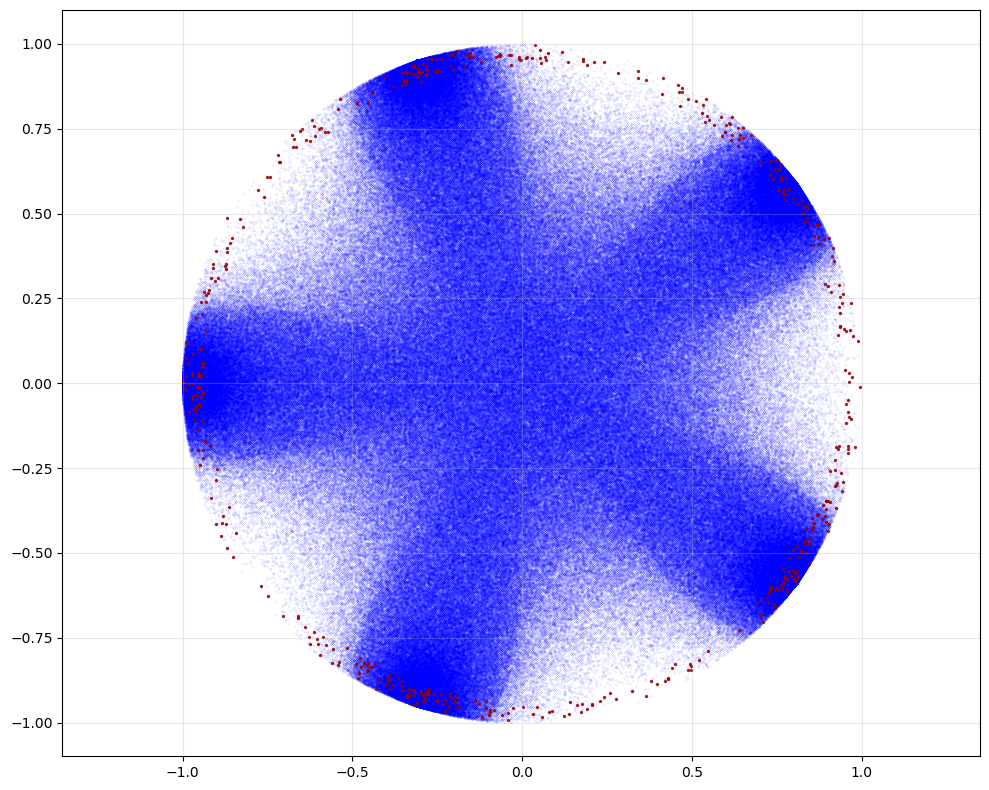

In [35]:
# Extract z0 (first column)
#z0 = pts_5mil_patch0[:, 2]
pt_x = np.real(pts_5mil_patch0[:, 2])
pt_y = np.imag(pts_5mil_patch0[:, 2])

loss_idx = find_satisfying_points(coeffs_T3, basis, k=500)
# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot points that don't satisfy the condition in blue
plt.scatter(pt_x, 
            pt_y, 
            c='blue', 
            alpha=0.6, 
            label='Normal points',
            s=.01)

# Plot points that satisfy the condition in red
plt.scatter(pt_x[loss_idx], 
            pt_y[loss_idx], 
            c='red', 
            alpha=0.8, 
            label='Equal modulus points',
            s=2,
            edgecolor='darkred',
            linewidth=1)

#plt.xlabel('Real(z₀)', fontsize=12)
#plt.ylabel('Imag(z₀)', fontsize=12)
#plt.title('Scatter Plot of Complex Points z₀\n(Red: |z₀|² = |z₁|² = |z₂|² = |z₃|²)', fontsize=14)
plt.grid(True, alpha=0.3)
#plt.legend()
plt.axis('equal')  # Equal aspect ratio


plt.tight_layout()
plt.show()

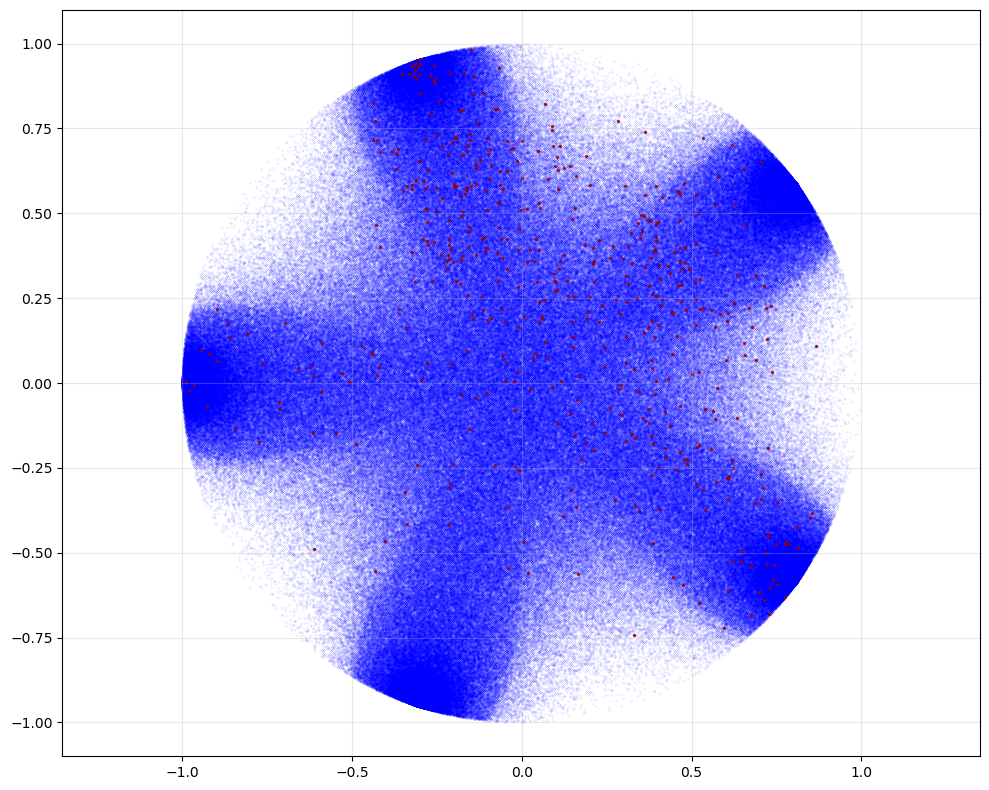

In [50]:
# Extract z0 (first column)
#z0 = pts_5mil_patch0[:, 2]
pt_x = np.real(pts_5mil_patch0[:, 1])
pt_y = np.imag(pts_5mil_patch0[:, 1])

loss_idx = find_satisfying_points(coeffs_random[5], basis, k=500)
# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot points that don't satisfy the condition in blue
plt.scatter(pt_x, 
            pt_y, 
            c='blue', 
            alpha=0.6, 
            label='Normal points',
            s=.01)

# Plot points that satisfy the condition in red
plt.scatter(pt_x[loss_idx], 
            pt_y[loss_idx], 
            c='red', 
            alpha=0.8, 
            label='Equal modulus points',
            s=2,
            edgecolor='darkred',
            linewidth=1)

#plt.xlabel('Real(z₀)', fontsize=12)
#plt.ylabel('Imag(z₀)', fontsize=12)
#plt.title('Scatter Plot of Complex Points z₀\n(Red: |z₀|² = |z₁|² = |z₂|² = |z₃|²)', fontsize=14)
plt.grid(True, alpha=0.3)
#plt.legend()
plt.axis('equal')  # Equal aspect ratio


plt.tight_layout()
plt.show()

In [11]:
# Main execution
if __name__ == "__main__":
 
    # points = jnp.array(np.load("fermat_quintic_points.npy"))

    
    # Optimize equations
    print("\nOptimizing equations...")
    coeffs, losses = optimize_equations(
        pts_5mil_patch0, 
        init_coeffs=None,
        learning_rate=0.01, 
        num_steps=3000,
        num_min_set=500,
        lambda_reg=0.1
    )
    
    # Analyze solution
   # analyze_solution(coeffs, points)
    
    # Save results
    #np.save("optimized_coefficients.npy", np.array(coeffs))
    #print("\nCoefficients saved to 'optimized_coefficients.npy'")


Optimizing equations...
Step 0, Loss: 0.789445
Step 10, Loss: 0.354575
Step 20, Loss: 0.259216
Step 30, Loss: 0.189749
Step 40, Loss: 0.145476
Step 50, Loss: 0.125534
Step 60, Loss: 0.116684
Step 70, Loss: 0.109738
Step 80, Loss: 0.107313
Step 90, Loss: 0.097546
Step 100, Loss: 0.103099
Step 110, Loss: 0.092896
Step 120, Loss: 0.089097
Step 130, Loss: 0.088657
Step 140, Loss: 0.090448
Step 150, Loss: 0.091509
Step 160, Loss: 0.085150
Step 170, Loss: 0.083741
Step 180, Loss: 0.089637
Step 190, Loss: 0.089110
Step 200, Loss: 0.083234
Step 210, Loss: 0.086429
Step 220, Loss: 0.088755
Step 230, Loss: 0.079913
Step 240, Loss: 0.085922
Step 250, Loss: 0.088851
Step 260, Loss: 0.083135
Step 270, Loss: 0.082393
Step 280, Loss: 0.085002
Step 290, Loss: 0.083401
Step 300, Loss: 0.086833
Step 310, Loss: 0.084627
Step 320, Loss: 0.084979
Step 330, Loss: 0.081495
Step 340, Loss: 0.081011
Step 350, Loss: 0.081043
Step 360, Loss: 0.077540
Step 370, Loss: 0.077071
Step 380, Loss: 0.076301
Step 390, L

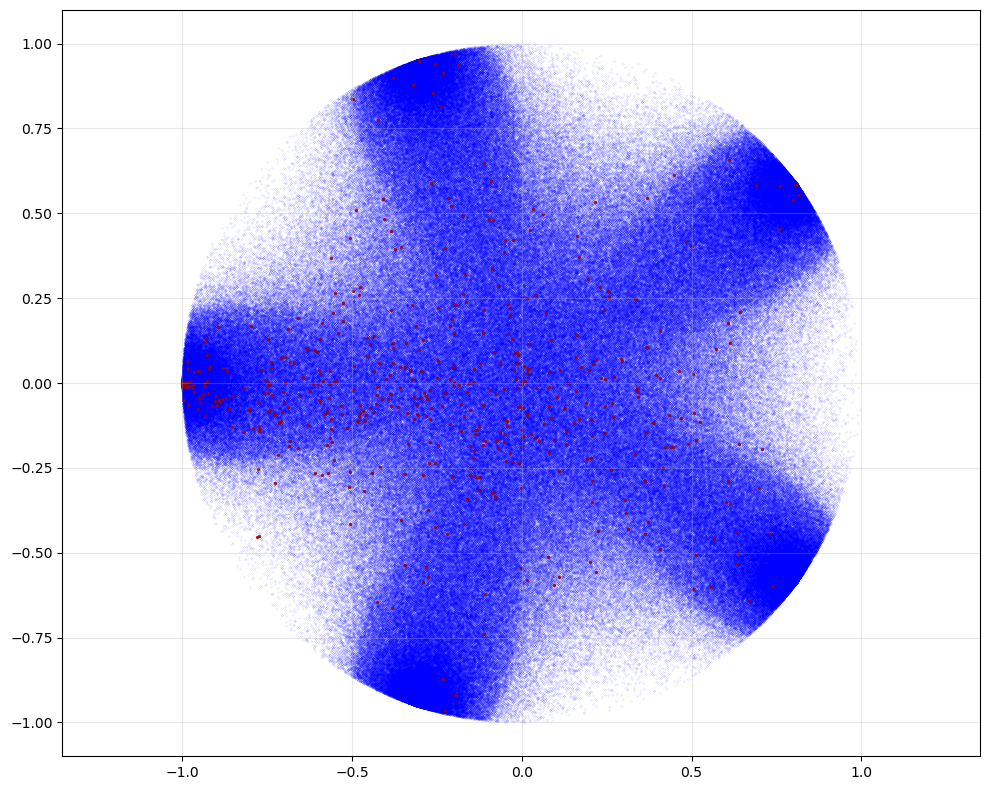

In [13]:
# Extract z0 (first column)
#z0 = pts_5mil_patch0[:, 2]
pt_x = np.real(pts_5mil_patch0[:, 1])
pt_y = np.imag(pts_5mil_patch0[:, 1])

loss_idx = find_satisfying_points(coeffs, basis, k=500)
# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot points that don't satisfy the condition in blue
plt.scatter(pt_x, 
            pt_y, 
            c='blue', 
            alpha=0.6, 
            label='Normal points',
            s=.01)

# Plot points that satisfy the condition in red
plt.scatter(pt_x[loss_idx], 
            pt_y[loss_idx], 
            c='red', 
            alpha=0.8, 
            label='Equal modulus points',
            s=2,
            edgecolor='darkred',
            linewidth=1)

#plt.xlabel('Real(z₀)', fontsize=12)
#plt.ylabel('Imag(z₀)', fontsize=12)
#plt.title('Scatter Plot of Complex Points z₀\n(Red: |z₀|² = |z₁|² = |z₂|² = |z₃|²)', fontsize=14)
plt.grid(True, alpha=0.3)
#plt.legend()
plt.axis('equal')  # Equal aspect ratio


plt.tight_layout()
plt.show()

In [14]:
loss_function(coeffs_RP3, basis, k=500, lambda_reg=0)

Array(0.50557095, dtype=float32)

In [15]:
coeffs

Array([[ 0.15187627,  0.6765426 , -0.29611582, -0.03355554,  0.1593351 ,
        -0.18810217, -0.26243627, -0.33545983,  0.2497773 , -0.21676423,
        -0.09701065,  0.04172419, -0.05008114, -0.12882687,  0.07476719,
         0.08380108,  0.0310185 , -0.00400769,  0.10407457,  0.01854185,
        -0.11133417, -0.00567307, -0.00547034,  0.06749806,  0.08261573],
       [-0.07179185,  0.04383859, -0.50023437, -0.127556  ,  0.18617685,
        -0.26303804,  0.21675128, -0.30152744, -0.5418362 ,  0.37978563,
        -0.00270785,  0.03467519,  0.05918996, -0.00361937, -0.033696  ,
         0.02116649,  0.06955177, -0.0529707 , -0.02146883,  0.01578098,
         0.08093172,  0.08980497, -0.02303816, -0.11446869, -0.06271297],
       [ 0.36940414, -0.12332167,  0.12510522,  0.34186843,  0.16072614,
        -0.5458463 , -0.11409377,  0.40813488,  0.14375769,  0.32600212,
         0.01173706,  0.05751769,  0.12723805, -0.10619254, -0.01916117,
         0.11599686,  0.04810943, -0.01158912,  0

In [16]:
pts_5mil_patch0[loss_idx]

Array([[ 1.        -0.0000000e+00j, -0.6437878 +1.6988866e-02j,
        -0.9749333 -3.2076228e-03j, -0.39201036-2.2725407e-03j,
        -0.19471683+2.6922844e-02j],
       [ 1.        +0.0000000e+00j, -0.21128139+1.2946304e-02j,
        -0.9199714 -6.6863991e-02j, -0.84468836+9.5717430e-02j,
         0.21100083-8.3274409e-02j],
       [ 1.        +0.0000000e+00j,  0.1299884 -1.7965227e-01j,
        -0.99871206-1.8758926e-03j, -0.25319314-4.6861921e-02j,
        -0.39914048+8.3705179e-02j],
       ...,
       [ 1.        +0.0000000e+00j,  0.34313995-2.7064616e-02j,
        -0.22746831+5.3202093e-02j, -0.98770547-6.9911820e-03j,
        -0.5900296 +5.8024962e-02j],
       [ 1.        +4.0818561e-17j, -0.0695284 +2.8723320e-01j,
        -0.9101185 +3.8136858e-02j, -0.8135871 +2.2021702e-02j,
        -0.6834379 -1.9682342e-01j],
       [ 1.        +0.0000000e+00j,  0.15345512-1.1762091e-01j,
        -0.98693156-2.0122308e-02j, -0.07797288-1.5020168e-01j,
         0.44403118-4.7549623e-01j]

In [19]:
loss_function(coeffs, basis, k=500, lambda_reg=1)

Array(0.07799078, dtype=float32)

In [18]:
loss_function_array(coeffs, basis, k=500)

Array([2.92171217e-06, 3.06210472e-06, 3.56342412e-06, 3.94316658e-06,
       4.60289266e-06, 5.49719653e-06, 8.09828816e-06, 9.23279822e-06,
       9.50132198e-06, 9.89924320e-06, 1.04866540e-05, 1.50235264e-05,
       1.56517635e-05, 1.69707091e-05, 1.74846700e-05, 1.93823125e-05,
       1.94668246e-05, 1.96530054e-05, 1.98844155e-05, 1.99077876e-05,
       2.01637395e-05, 2.13383701e-05, 2.16893895e-05, 2.29843426e-05,
       2.35865446e-05, 2.49648492e-05, 2.49810546e-05, 2.69654320e-05,
       2.70482014e-05, 2.72398538e-05, 2.80510249e-05, 2.89908385e-05,
       2.95909813e-05, 3.16724436e-05, 3.19805804e-05, 3.20469917e-05,
       3.22335363e-05, 3.29046597e-05, 3.32286654e-05, 3.45521839e-05,
       3.56233832e-05, 3.58431935e-05, 3.61013736e-05, 3.73570292e-05,
       3.78902187e-05, 3.81980426e-05, 3.86687097e-05, 3.92365655e-05,
       3.93947812e-05, 3.95387433e-05, 4.02536243e-05, 4.09763925e-05,
       4.13390153e-05, 4.16365983e-05, 4.19796488e-05, 4.26321967e-05,
      

In [23]:
from collections import defaultdict

def combine_to_complex_equations(labels, coeffs):
    """
    Convert equations from Re/Im basis to zi*zjbar basis using:
    Im(zi*zjbar) = (zi*zjbar - zj*zibar)/(2i)
    Re(zi*zjbar) = (zi*zjbar + zj*zibar)/2
    
    Parameters:
    labels: array of strings like 'Im(z0*z1bar)', 'Re(z0*z1bar)'
    coeffs: 3x25 array of coefficients
    
    Returns:
    List of 3 strings representing the equations in terms of zi*zjbar
    """
    equations = []
    
    for eq_idx in range(coeffs.shape[0]):
        # Dictionary to store coefficients for each zi*zjbar term
        terms = defaultdict(complex)
        
        # Process each label and its coefficient
        for label_idx, label in enumerate(labels):
            coeff = coeffs[eq_idx, label_idx]
            
            # Skip if coefficient is very small
            if abs(coeff) < 1e-10:
                continue
            
            # Extract the zi and zj indices
            if label.startswith('Im(') and label.endswith(')'):
                # Extract 'zi*zjbar' from 'Im(zi*zjbar)'
                inner = label[3:-1]  # e.g., 'z0*z1bar'
                parts = inner.split('*')
                zi = parts[0]  # e.g., 'z0'
                zj = parts[1].replace('bar', '')  # e.g., 'z1'
                
                # Im(zi*zjbar) = (zi*zjbar - zj*zibar)/(2i)
                # Coefficient for zi*zjbar: coeff/(2i) = -coeff*i/2
                # Coefficient for zj*zibar: -coeff/(2i) = coeff*i/2
                
                terms[f"{zi}*{zj}bar"] += complex(0, -coeff/2)  # -i*coeff/2
                terms[f"{zj}*{zi}bar"] += complex(0, coeff/2)   # i*coeff/2
                
            elif label.startswith('Re(') and label.endswith(')'):
                # Extract 'zi*zjbar' from 'Re(zi*zjbar)'
                inner = label[3:-1]  # e.g., 'z0*z1bar'
                parts = inner.split('*')
                zi = parts[0]  # e.g., 'z0'
                zj = parts[1].replace('bar', '')  # e.g., 'z1'
                
                # Re(zi*zjbar) = (zi*zjbar + zj*zibar)/2
                # Coefficient for both zi*zjbar and zj*zibar: coeff/2
                
                terms[f"{zi}*{zj}bar"] += complex(coeff/2, 0)
                terms[f"{zj}*{zi}bar"] += complex(coeff/2, 0)
        
        # Build the equation string
        equation_parts = []
        for term in sorted(terms.keys()):
            coeff_complex = terms[term]
            
            # Skip if coefficient is essentially zero
            if abs(coeff_complex) < 1e-10:
                continue
            
            # Format the complex coefficient
            real_part = coeff_complex.real
            imag_part = coeff_complex.imag
            
            if abs(imag_part) < 1e-10:
                # Only real part
                coeff_str = f"{real_part:.6f}"
            elif abs(real_part) < 1e-10:
                # Only imaginary part
                if abs(imag_part - 1) < 1e-10:
                    coeff_str = "i"
                elif abs(imag_part + 1) < 1e-10:
                    coeff_str = "-i"
                else:
                    coeff_str = f"{imag_part:.6f}i"
            else:
                # Both real and imaginary parts
                if imag_part >= 0:
                    coeff_str = f"({real_part:.6f}+{imag_part:.6f}i)"
                else:
                    coeff_str = f"({real_part:.6f}{imag_part:.6f}i)"
            
            # Add to equation
            if equation_parts:
                if coeff_str.startswith('-'):
                    equation_parts.append(f" {coeff_str}*{term}")
                else:
                    equation_parts.append(f" + {coeff_str}*{term}")
            else:
                equation_parts.append(f"{coeff_str}*{term}")
        
        equation = "".join(equation_parts) + " = 0"
        equations.append(equation)
    
    return equations

In [29]:
equations = combine_to_complex_equations(labels, coeffs)

# Print the equations
for i, eq in enumerate(equations):
    print(f"Equation {i+1}:")
    print(eq)
    print()

Equation 1:
-0.097011*z0*z0bar + (0.020862-0.075938i)*z0*z1bar + (-0.025041-0.338271i)*z0*z2bar + (-0.064413+0.148058i)*z0*z3bar + (0.037384+0.016778i)*z0*z4bar + (0.020862+0.075938i)*z1*z0bar + 0.083801*z1*z1bar + (0.015509-0.079668i)*z1*z2bar + (-0.002004+0.094051i)*z1*z3bar + (0.052037+0.131218i)*z1*z4bar + (-0.025041+0.338271i)*z2*z0bar + (0.015509+0.079668i)*z2*z1bar + 0.018542*z2*z2bar + (-0.055667+0.167730i)*z2*z3bar + (-0.002837-0.124889i)*z2*z4bar + (-0.064413-0.148058i)*z3*z0bar + (-0.002004-0.094051i)*z3*z1bar + (-0.055667-0.167730i)*z3*z2bar -0.005470*z3*z3bar + (0.033749+0.108382i)*z3*z4bar + (0.037384-0.016778i)*z4*z0bar + (0.052037-0.131218i)*z4*z1bar + (-0.002837+0.124889i)*z4*z2bar + (0.033749-0.108382i)*z4*z3bar + 0.082616*z4*z4bar = 0

Equation 2:
-0.002708*z0*z0bar + (0.017338+0.035896i)*z0*z1bar + (0.029595-0.021919i)*z0*z2bar + (-0.001810+0.250117i)*z0*z3bar + (-0.016848+0.063778i)*z0*z4bar + (0.017338-0.035896i)*z1*z0bar + 0.021166*z1*z1bar + (0.034776-0.093088i)

In [25]:
coeffs_RP3

Array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [30]:
@jit
def scale_to_max_abs(coeffs: jnp.ndarray) -> jnp.ndarray:
    """Scale each row of coefficients so that the largest absolute value equals 1."""
    max_abs = jnp.max(jnp.abs(coeffs), axis=1, keepdims=True)
    coeffs_scaled = coeffs / max_abs
    return coeffs_scaled

In [32]:
coeffs_max_abs = scale_to_max_abs(coeffs)
equations = combine_to_complex_equations(labels, coeffs_max_abs)

# Print the equations
for i, eq in enumerate(equations):
    print(f"Equation {i+1}:")
    print(eq)
    print()

Equation 1:
-0.143392*z0*z0bar + (0.030836-0.112244i)*z0*z1bar + (-0.037013-0.500000i)*z0*z2bar + (-0.095210+0.218845i)*z0*z3bar + (0.055257+0.024799i)*z0*z4bar + (0.030836+0.112244i)*z1*z0bar + 0.123867*z1*z1bar + (0.022924-0.117757i)*z1*z2bar + (-0.002962+0.139017i)*z1*z3bar + (0.076916+0.193954i)*z1*z4bar + (-0.037013+0.500000i)*z2*z0bar + (0.022924+0.117757i)*z2*z1bar + 0.027407*z2*z2bar + (-0.082282+0.247922i)*z2*z3bar + (-0.004193-0.184598i)*z2*z4bar + (-0.095210-0.218845i)*z3*z0bar + (-0.002962-0.139017i)*z3*z1bar + (-0.082282-0.247922i)*z3*z2bar -0.008086*z3*z3bar + (0.049885+0.160200i)*z3*z4bar + (0.055257-0.024799i)*z4*z0bar + (0.076916-0.193954i)*z4*z1bar + (-0.004193+0.184598i)*z4*z2bar + (0.049885-0.160200i)*z4*z3bar + 0.122115*z4*z4bar = 0

Equation 2:
-0.004998*z0*z0bar + (0.031998+0.066249i)*z0*z1bar + (0.054620-0.040454i)*z0*z2bar + (-0.003340+0.461610i)*z0*z3bar + (-0.031094+0.117707i)*z0*z4bar + (0.031998-0.066249i)*z1*z0bar + 0.039064*z1*z1bar + (0.064182-0.171802i)

In [33]:
coeffs_max_abs

Array([[ 0.22448885,  1.        , -0.43768984, -0.04959856,  0.23551379,
        -0.27803448, -0.38790798, -0.49584436,  0.3691967 , -0.32039997,
        -0.14339179,  0.06167267, -0.07402512, -0.19041947,  0.11051364,
         0.12386668,  0.04584855, -0.00592378,  0.15383299,  0.02740677,
        -0.16456345, -0.00838539, -0.00808573,  0.09976912,  0.12211461],
       [-0.13249733,  0.08090746, -0.92322063, -0.23541431,  0.34360355,
        -0.48545673,  0.400031  , -0.55649185, -1.        ,  0.7009233 ,
        -0.00499755,  0.0639957 ,  0.10923958, -0.00667983, -0.06218854,
         0.03906437,  0.1283631 , -0.09776146, -0.03962237,  0.029125  ,
         0.14936566,  0.16574192, -0.04251867, -0.21126068, -0.11574157],
       [ 0.6767549 , -0.22592747,  0.22919495,  0.626309  ,  0.2944531 ,
        -1.        , -0.20902179,  0.7477103 ,  0.2633666 ,  0.59724164,
         0.0215025 ,  0.10537342,  0.23310235, -0.1945466 , -0.03510359,
         0.21250829,  0.08813731, -0.02123147,  0